# 01 — What does LayoutLMv3 see?

**Goal:** look inside Novelty 1's first stage. Before chunking, `src/layout.py` labels every
line of every page with one of 11 DocLayNet region types (text, table, section header, …)
and merges lines into regions. Everything downstream — chunk boundaries, the region filter,
the region analytics — inherits these labels. So: are they any good?

**Document:** US FDA prescribing information for metformin ER tablets (26 pages, public domain),
`data/samples/metformin_er_fda_label.pdf`.

**You will see:** (1) the two coordinate systems a layout model juggles, (2) detected regions
drawn on real pages, (3) which labels the model uses and how confident it is, (4) where it fails.

In [1]:
# Setup — make `config` and `src` importable from notebooks/, quiet the logs, apply the chart style.
import os, sys, warnings
from pathlib import Path
os.environ["TQDM_DISABLE"] = "1"                 # no progress bars in saved outputs
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "notebooks")]
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()                 # hide HuggingFace load chatter
from huggingface_hub.utils import logging as hub_logging
hub_logging.set_verbosity_error()                # ...and Hub server notices

import _viz                                      # shared chart style (notebooks/_viz.py)
_viz.apply()
PDF = ROOT / "data" / "samples" / "metformin_er_fda_label.pdf"

## 1. Two coordinate systems

> **LEARN THIS — PDF points vs. pixels vs. 0–1000.** pdfplumber reports word boxes in *PDF points*
> (1/72 inch, origin top-left). The page is rendered to an image at 200 DPI for LayoutLMv3's vision
> branch, so image pixels = points × 200/72. LayoutLMv3 itself wants neither: it takes boxes
> *normalized to 0–1000*, so that one model works for every page size. Mixing any two of these is the
> classic silent bug — boxes land in the wrong place and nothing errors. Below, the scale is
> **measured** from the data rather than assumed.

In [2]:
from src.ingestion import get_page_summary, load_pdf_pages

pages = load_pdf_pages(PDF)
p0 = pages[0]
scale = p0.image.width / p0.width                 # measured, not assumed
print(get_page_summary(pages))
print(f"page size: {p0.width:.0f} x {p0.height:.0f} pt  ->  image {p0.image.width} x {p0.image.height} px")
print(f"scale = {scale:.4f} px/pt   (200 DPI / 72 = {200 / 72:.4f})")

{'total_pages': 26, 'total_words': 8888, 'scanned_pages': 0, 'scanned_page_numbers': []}
page size: 612 x 792 pt  ->  image 1700 x 2200 px
scale = 2.7778 px/pt   (200 DPI / 72 = 2.7778)


## 2. Run the detector

The model labels each **line** (its tokens' probabilities are averaged per line — see
`LayoutDetector._label_lines`), then lines are merged into **regions** by geometry. A region's
`confidence` is the mean confidence of its lines. Lines under 0.5 confidence fall back to `text`.

In [3]:
import pandas as pd                               # pandas: the table view that accompanies every chart

from src.layout import LayoutDetector

detector = LayoutDetector()
regions = detector.detect_document(pages)
df = pd.DataFrame({
    "page": [r.page_num + 1 for r in regions],
    "label": [r.label for r in regions],
    "words": [len(r.words) for r in regions],
    "confidence": [round(r.confidence, 3) for r in regions],
    "text": [" ".join(r.text.split())[:70] for r in regions],
})
print(f"{len(regions)} regions on {len(pages)} pages")
df.head(10)

[LayoutDetector] Loading model: Kwan0/layoutlmv3-base-finetune-DocLayNet-100k
[LayoutDetector] First run downloads ~500MB — be patient.


[LayoutDetector] Ready on cuda. Labels: ['caption', 'footnote', 'formula', 'list_item', 'page_footer', 'page_header', 'picture', 'section_header', 'table', 'text', 'title']


287 regions on 26 pages


,page,label,words,confidence,text
0,1,section_header,6,0.544,METFORMIN HYDROCHLORIDE- metformin hydrochlori...
1,1,text,5,0.693,release Granules India Ltd ----------
2,1,section_header,8,0.656,HIGHLIGHTS OF PRESCRIBING INFORMATION METFORMI...
3,1,text,27,0.975,These highlights do not include all the inform...
4,1,text,7,0.960,METFORMIN HYDROCHLORIDE extended-release table...
5,1,text,4,0.772,Initial U.S. Approval: 1995
6,1,section_header,3,0.953,WARNING: LACTIC ACIDOSIS
7,1,text,138,0.987,See full prescribing information for complete ...
8,1,section_header,3,0.984,RECENT MAJOR CHANGES
9,1,text,3,0.498,Boxed Warning 08/2026


## 3. Regions on the page

Three pages with different structure: the two-column *Highlights* summary (page 1), a page of
numbered sections (page 5), and a page with a pharmacokinetics table (page 15). Colour follows the three
labels that matter most for chunking; everything else is grey. Every box also carries its label as
text, so colour is never the only cue.

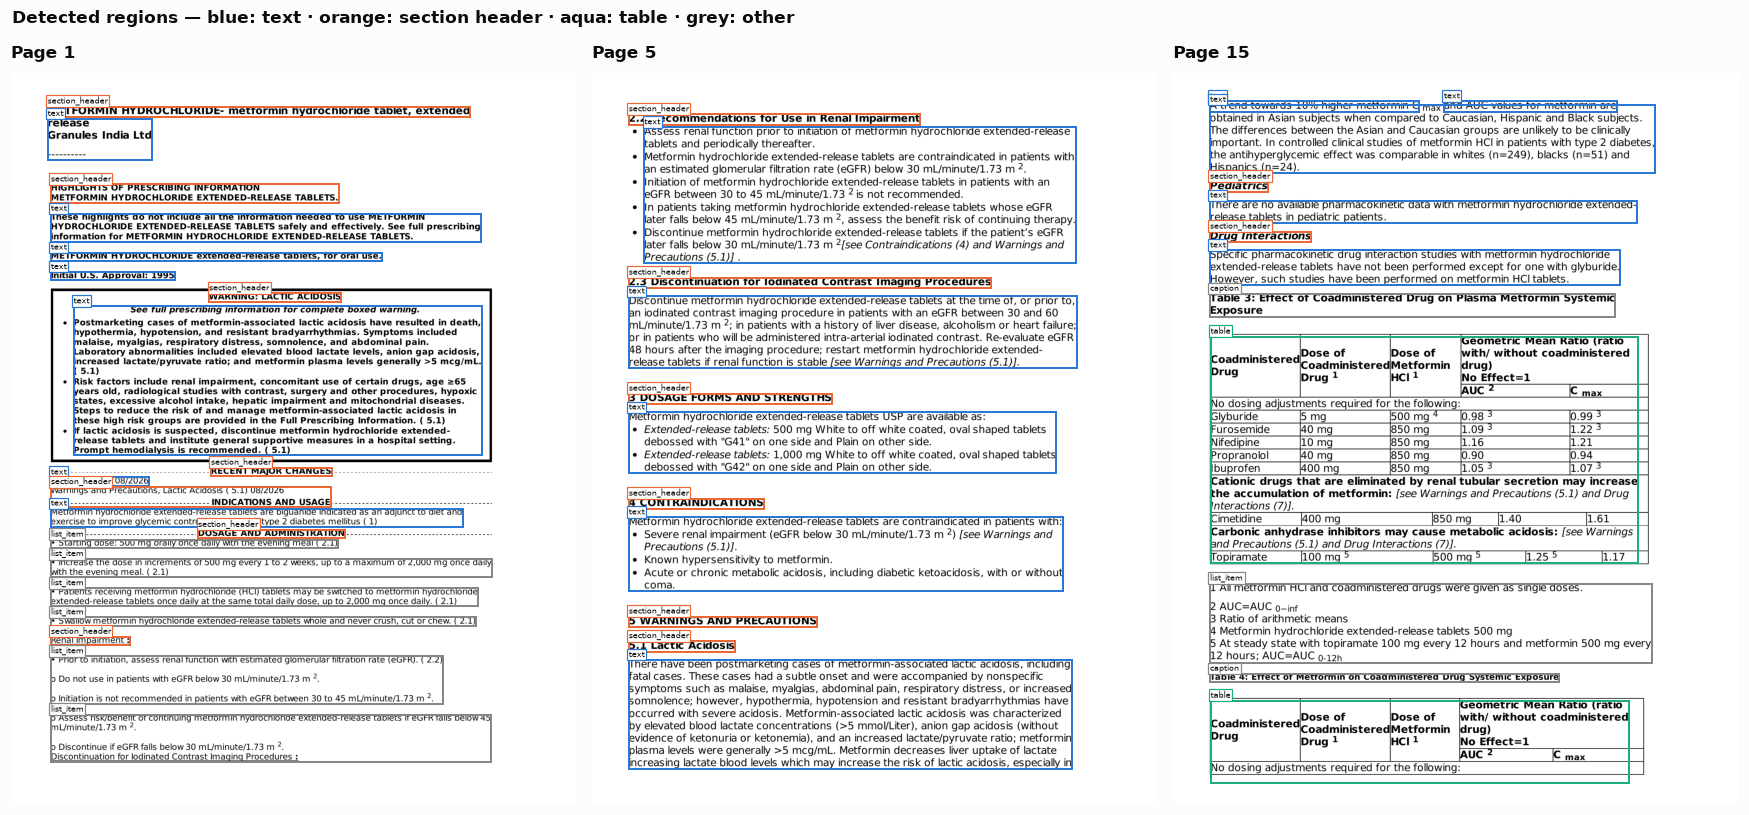

In [4]:
import matplotlib.pyplot as plt                   # matplotlib: static figures that render on GitHub
from matplotlib.patches import Rectangle

LABEL_COLOR = {"text": _viz.SERIES[0], "section_header": _viz.SERIES[1], "table": _viz.SERIES[2]}


def draw_regions(ax, page, page_regions) -> None:
    """Draw a page image with its regions as labelled boxes (PDF points -> pixels)."""
    s = page.image.width / page.width
    ax.imshow(page.image)
    ax.set_axis_off()
    for r in page_regions:
        x0, y0, x1, y1 = (v * s for v in r.bbox)
        color = LABEL_COLOR.get(r.label, _viz.MUTED)
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color, linewidth=1.3))
        ax.text(x0, y0 - 3, r.label, fontsize=5.5, color=_viz.INK, va="bottom",
                bbox=dict(facecolor="white", edgecolor=color, linewidth=0.8, pad=1.0))


fig, axes = plt.subplots(1, 3, figsize=(16, 7.8))
for ax, page_no in zip(axes, [1, 5, 15]):
    draw_regions(ax, pages[page_no - 1], [r for r in regions if r.page_num == page_no - 1])
    ax.set_title(f"Page {page_no}", loc="left")
fig.suptitle("Detected regions — blue: text · orange: section header · aqua: table · grey: other",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Which labels does the model use?

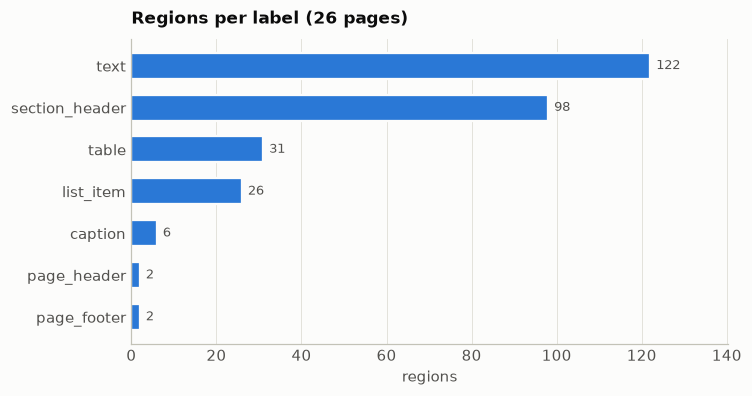

label,text,section_header,table,list_item,caption,page_header,page_footer
regions,122,98,31,26,6,2,2


In [5]:
counts = df["label"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3.6))
_viz.hbar(ax, list(counts.index), list(counts.values), fmt="{:.0f}")
ax.set_title("Regions per label (26 pages)")
ax.set_xlabel("regions")
plt.show()
counts.to_frame("regions").T

## 5. How confident is it?

Each dot is one region. The line at 0.5 is the fallback threshold: lines below it are relabelled `text`.

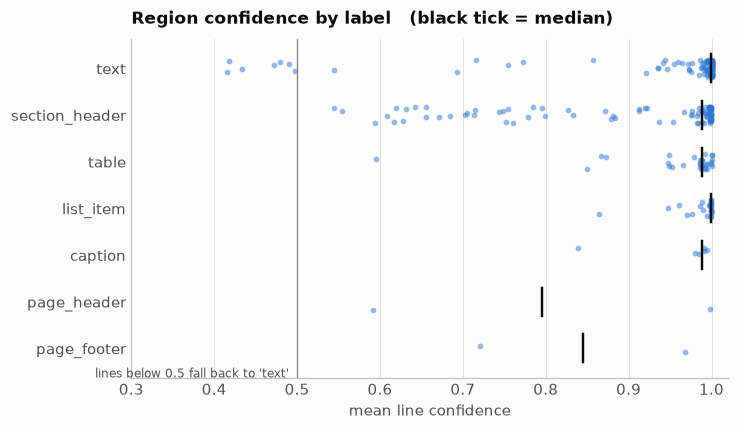

,count,min,50%,max
label,,,,
caption,6.0,0.839,0.988,0.994
list_item,26.0,0.864,0.999,1.000
page_footer,2.0,0.721,0.844,0.968
page_header,2.0,0.592,0.795,0.998
section_header,98.0,0.544,0.989,0.999
table,31.0,0.595,0.988,1.000
text,122.0,0.415,0.999,1.000


In [6]:
import numpy as np                                # numpy: jitter for the strip plot

from config import LAYOUTLM_CONFIDENCE_THRESHOLD

order = list(counts.index)
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7, 4))
for i, label in enumerate(order[::-1]):
    conf = df.loc[df["label"] == label, "confidence"].to_numpy()
    ax.scatter(conf, i + rng.uniform(-0.18, 0.18, len(conf)), s=14, color=_viz.SERIES[0],
               alpha=0.5, linewidths=0)
    ax.plot([np.median(conf)] * 2, [i - 0.3, i + 0.3], color=_viz.INK, linewidth=1.6)
ax.axvline(LAYOUTLM_CONFIDENCE_THRESHOLD, color=_viz.MUTED, linewidth=0.9)
ax.text(LAYOUTLM_CONFIDENCE_THRESHOLD - 0.01, -0.55, "lines below 0.5 fall back to 'text'",
        fontsize=8, color=_viz.INK_2, ha="right", va="center")
ax.set_yticks(range(len(order)), order[::-1])
ax.grid(axis="y", visible=False)
ax.set_xlim(0.3, 1.02)
ax.set_title("Region confidence by label   (black tick = median)")
ax.set_xlabel("mean line confidence")
plt.show()
df.groupby("label")["confidence"].describe()[["count", "min", "50%", "max"]].round(3)

## 6. Where it goes wrong

Two failure modes matter for chunking:
* **Oversized section headers** — a "heading" with dozens of tokens is really a heading *merged* with
  the content below it (the geometric grouping joined them), so a paragraph gets the wrong label.
* **Headings split from their content** — a short heading becomes its own tiny chunk, cut off from
  the list it introduces. Notebook 02 measures what this costs retrieval.

In [7]:
from src.chunker import count_tokens

df["tokens"] = [count_tokens(r.text) for r in regions]
headers = df[df["label"] == "section_header"]
big = headers[headers["tokens"] > 25].sort_values("tokens", ascending=False)
short = headers[headers["tokens"] <= 8]
print(f"section_header regions: {len(headers)}  |  > 25 tokens (merged with content): {len(big)}"
      f"  |  <= 8 tokens (bare headings): {len(short)}")
big[["page", "tokens", "confidence", "text"]].head(6)

section_header regions: 98  |  > 25 tokens (merged with content): 7  |  <= 8 tokens (bare headings): 68


,page,tokens,confidence,text
215,20,183,0.827,PATIENT INFORMATION Metformin Hydrochloride (m...
238,22,63,0.744,What are the possible side effects ofmetformin...
31,2,44,0.785,"To report SUSPECTED ADVERSE REACTIONS, contact..."
223,21,37,0.760,See “What are the possible side effects of met...
253,23,34,0.752,Keep metformin hydrochloride extended-release ...
21,2,31,0.833,DOSAGE FORMS AND STRENGTHS Metformin Hydrochlo...


In [8]:
low = df[df["confidence"] < 0.7].sort_values("confidence")
print(f"regions with confidence < 0.7: {len(low)} of {len(df)} ({len(low) / len(df):.0%})")
low[["page", "label", "confidence", "text"]].head(8)

regions with confidence < 0.7: 24 of 287 (8%)


,page,label,confidence,text
286,26,text,0.415,Granules India Ltd
261,24,text,0.418,Product Information
264,24,text,0.434,Active Ingredient/Active Moiety
285,26,text,0.472,Revised: 9/2026
266,24,text,0.479,Inactive Ingredients
260,24,text,0.490,"metformin hydrochloride tablet, extended release"
9,1,text,0.498,Boxed Warning 08/2026
0,1,section_header,0.544,METFORMIN HYDROCHLORIDE- metformin hydrochlori...


## Findings

**Coordinates are right.** The measured scale (2.7778 px/pt) equals 200/72, and every box in
section 3 sits on its text — the PDF-points → pixels conversion is correct.

**Tables are found whole.** On page 15 both pharmacokinetics tables are single `table` regions, header
rows included, so each becomes one chunk (or a sliding-window split if it exceeds 250 tokens) instead
of being cut wherever a character count runs out.

**Headings are the weak spot — and they decide chunk boundaries.**
* `section_header` has the widest confidence spread of any label (many regions between 0.55 and 0.9):
  the model is least sure about the label that matters most for where chunks start and end.
* Most headings are *bare* — a few tokens, detected as their own region, so they become tiny chunks cut
  off from the list or paragraph they introduce. Notebook 02 measures what that costs retrieval.
* A few "headings" are really heading + content merged by the geometric line grouping (the largest,
  on the patient-information page, is 183 tokens).

**Low confidence is mostly harmless here.** The regions under 0.5 are the product-data footer
("Revised: 9/2026", "Granules India Ltd", "Inactive Ingredients"); falling back to `text` is fine.

Counts for this document, computed:

In [9]:
print(f"* {len(regions)} regions; {counts.get('text', 0)} text, {counts.get('section_header', 0)} section headers, "
      f"{counts.get('table', 0)} tables, {counts.get('list_item', 0)} list items.")
print(f"* Median region confidence {df['confidence'].median():.2f}; "
      f"{(df['confidence'] < 0.7).mean():.0%} of regions below 0.7.")
print(f"* {len(big)} section headers are > 25 tokens (heading merged with content); "
      f"{len(short)} are bare headings of <= 8 tokens that become tiny standalone chunks.")

* 287 regions; 122 text, 98 section headers, 31 tables, 26 list items.
* Median region confidence 1.00; 8% of regions below 0.7.
* 7 section headers are > 25 tokens (heading merged with content); 68 are bare headings of <= 8 tokens that become tiny standalone chunks.
